<a href="https://colab.research.google.com/github/akanksha1723/AI_Projects/blob/main/Day11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical
import numpy as np

print (f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [ ]:
campus = {
    "I love machine learning",
    "Machine learning is fascinating",
    "I want to learn more about machine learning"
    "I like to work with machine learning algorithms",
    "Machine learning is a powerful tool"
}

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(campus)
word_index = tokenizer.word_index
total_words = len(word_index) + 1
print(f"Word Index: {word_index}")
print(f"Total Words: {total_words}")

Word Index: {'machine': 1, 'learning': 2, 'is': 3, 'i': 4, 'to': 5, 'fascinating': 6, 'love': 7, 'a': 8, 'powerful': 9, 'tool': 10, 'want': 11, 'learn': 12, 'more': 13, 'about': 14, 'learningi': 15, 'like': 16, 'work': 17, 'with': 18, 'algorithms': 19}
Total Words: 20


In [ ]:
input_sequences = []
for line in campus:
  token_list = tokenizer.texts_to_sequences([line])[0]
  for i in range(1, len(token_list)):
    n_gram_sequence = token_list[:i+1]
    input_sequences.append(n_gram_sequence)

print(f"\nSample Sequence: {input_sequences[:5]}")


Sample Sequence: [[1, 2], [1, 2, 3], [1, 2, 3, 6], [4, 7], [4, 7, 1]]


In [ ]:
max_sequence_len = max([len(x) for x in input_sequences])
print(f"Max Sequence Length: {max_sequence_len}")

padded_sequences = np.array(tf.keras.preprocessing.sequence.pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))
print(f"\nPadded Sequences: {padded_sequences}")

Max Sequence Length: 15

Padded Sequences: [[ 0  0  0  0  0  0  0  0  0  0  0  0  0  1  2]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  1  2  3]
 [ 0  0  0  0  0  0  0  0  0  0  0  1  2  3  6]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  4  7]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  4  7  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  4  7  1  2]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  1  2]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  1  2  3]
 [ 0  0  0  0  0  0  0  0  0  0  0  1  2  3  8]
 [ 0  0  0  0  0  0  0  0  0  0  1  2  3  8  9]
 [ 0  0  0  0  0  0  0  0  0  1  2  3  8  9 10]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  4 11]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  4 11  5]
 [ 0  0  0  0  0  0  0  0  0  0  0  4 11  5 12]
 [ 0  0  0  0  0  0  0  0  0  0  4 11  5 12 13]
 [ 0  0  0  0  0  0  0  0  0  4 11  5 12 13 14]
 [ 0  0  0  0  0  0  0  0  4 11  5 12 13 14  1]
 [ 0  0  0  0  0  0  0  4 11  5 12 13 14  1 15]
 [ 0  0  0  0  0  0  4 11  5 12 13 14  1 15 16]
 [ 0  0  0  0  0  4 11  5 12 13 14  1 15 16  

In [ ]:
x,labels=padded_sequences[:,:-1],padded_sequences[:,-1]
y=to_categorical(labels,num_classes=total_words)

print(f"\nShape of x (predictors): {x.shape}")
print(f"Shape of y (labels): {y.shape}")


Shape of x (predictors): (25, 14)
Shape of y (labels): (25, 20)


In [ ]:
model = Sequential()
model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))
model.add(LSTM(150))
model.add(Dense(total_words, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0800 - loss: 2.9977
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.1200 - loss: 2.9841
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2400 - loss: 2.9701
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2000 - loss: 2.9544
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.2000 - loss: 2.9359
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.1600 - loss: 2.9131
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1600 - loss: 2.8839
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.1600 - loss: 2.8465
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.1600 - loss: 2.8016
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1600 - loss: 2.7622
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1600 - loss: 2.7638
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.1600 - los

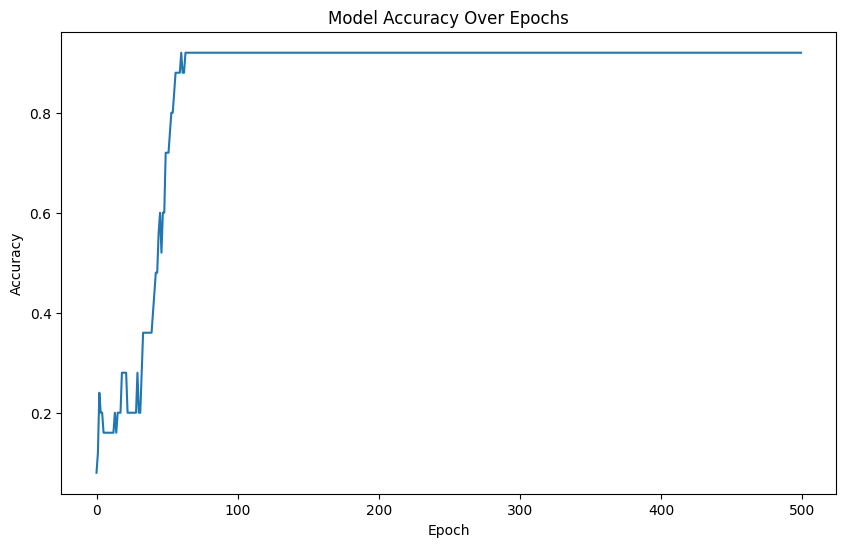

In [ ]:
history = model.fit(x,y,epochs=500, verbose=1)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy Over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

In [ ]:
def predict_next_word(seed_text, n_words):
  for _ in range(n_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = tf.keras.preprocessing.sequence.pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted_probabilities = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted_probabilities)
    output_word = ""
    for word, index in tokenizer.word_index.items():
      if index == predicted_word_index:
        output_word = word
        break
    seed_text += " " + output_word
  return seed_text

In [ ]:
seed_text = "I love"
predicted_text = predict_next_word(seed_text, 2)
print(f"Seed Text: {seed_text}")
print(f"Predicted text: {predicted_text}")

seed_text2 = "Machine learning is"
predicted_text2 = predict_next_word(seed_text2, 1)
print(f"Seed Text: {seed_text2}")
print(f"Predicted text: {predicted_text2}")


Seed Text: I love
Predicted text: I love machine learning
Seed Text: Machine learning is
Predicted text: Machine learning is a


In [ ]:
seed_text = "I like"
predicted_text = predict_next_word(seed_text, 1)
print(f"Seed Text: {seed_text}")
print(f"Predicted text: {predicted_text}")

Seed Text: I like
Predicted text: I like machine
